# Time Series EDA: Warsaw Apartments

Exploratory data analysis of monthly aggregated metrics for Warsaw's apartment market. This notebook uses pre-computed city-month marts from the DuckDB database.

**Analysis includes:**
- Monthly median price trends for sale and rent
- Month-over-month price changes
- Listing volume trends over time

In [10]:
from __future__ import annotations

from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## Setup & Imports

Import required libraries for time series analysis.

In [11]:
import importlib
from apartments import viz
importlib.reload(viz)

from apartments.viz import (
    build_view,
    plot_hist,
    plot_box,
    plot_scatter,
    plot_box_by_category
)



In [12]:
from apartments.rental_yield import make_yield_df, yield_summary

In [13]:
PROJECT_ROOT = Path("..").resolve()  # notebooks/ -> project root
DB_PATH = PROJECT_ROOT / "data" / "processed" / "apartments.duckdb"

CITY = "Warszawa"

In [14]:
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Load Time Series Data

Load monthly aggregated metrics from DuckDB mart views (mart_city_month_sale and mart_city_month_rent).

In [15]:

con = duckdb.connect(DB_PATH, read_only=True)

df_ts_sale = con.execute("""
    SELECT
        month,
        city,
        n_listings,
        median_ppm2,
        p25_ppm2,
        p75_ppm2,
        avg_ppm2
    FROM mart_city_month_sale
    ORDER BY month
""").df()

df_ts_rent = con.execute("""
    SELECT
        month,
        city,
        n_listings,
        median_ppm2,
        p25_ppm2,
        p75_ppm2,
        avg_ppm2
    FROM mart_city_month_rent
    ORDER BY month
""").df()

con.close()

df_ts_sale.head(), df_ts_rent.head()

(       month      city  n_listings   median_ppm2      p25_ppm2      p75_ppm2  \
 0 2023-08-01  warszawa        4069  14872.340426  12364.261168  17905.660377   
 1 2023-09-01  warszawa        3663  15471.698113  12939.119704  18486.388227   
 2 2023-10-01  warszawa        3527  15800.000000  13290.661013  18749.519231   
 3 2023-11-01  warszawa        3421  16000.000000  13708.002056  18918.918919   
 4 2023-12-01  warszawa        3574  16913.329161  14285.714286  19720.000000   
 
        avg_ppm2  
 0  15512.675103  
 1  15966.622834  
 2  16326.648946  
 3  16606.070983  
 4  17322.976903  ,
        month      city  n_listings  median_ppm2   p25_ppm2   p75_ppm2  \
 0 2023-11-01  warszawa        2503    80.357143  67.681770  97.449792   
 1 2023-12-01  warszawa        2410    80.000000  67.456395  96.153846   
 2 2024-01-01  warszawa        2410    80.000000  67.456395  96.153846   
 3 2024-02-01  warszawa        2427    80.952381  68.722826  98.333333   
 4 2024-03-01  warszawa    

In [16]:
df_ts_sale["median_ppm2_mom"] = df_ts_sale["median_ppm2"].pct_change() * 100
df_ts_rent["median_ppm2_mom"] = df_ts_rent["median_ppm2"].pct_change() * 100

df_ts_sale[["month", "median_ppm2", "median_ppm2_mom", "n_listings"]].tail()


,month,median_ppm2,median_ppm2_mom,n_listings
6,2024-02-01,17467.253047,0.880803,3600
7,2024-03-01,17714.285714,1.414262,3822
8,2024-04-01,17842.105263,0.721562,4557
9,2024-05-01,17871.994746,0.167522,4952
10,2024-06-01,17955.217575,0.465661,5282


## Month-over-Month Changes

Calculate percentage change in median price from previous month.

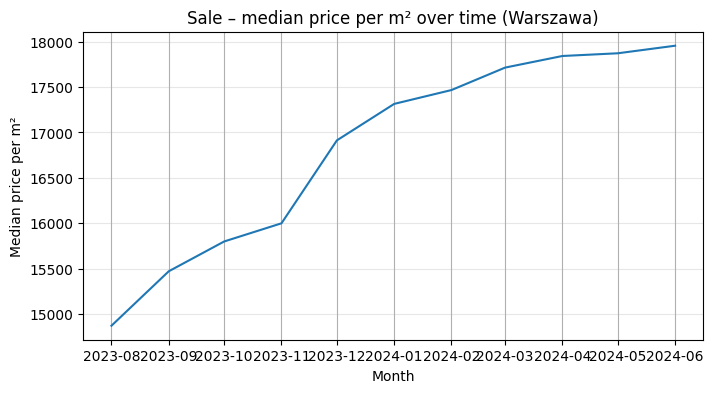

In [17]:
plt.close("all")
plt.figure(figsize=(8, 4))
plt.plot(df_ts_sale["month"], df_ts_sale["median_ppm2"])
plt.title("Sale – median price per m² over time (Warszawa)")
plt.xlabel("Month")
plt.ylabel("Median price per m²")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Price Trend Visualizations

Plot median price per m² over time for sale and rental markets.

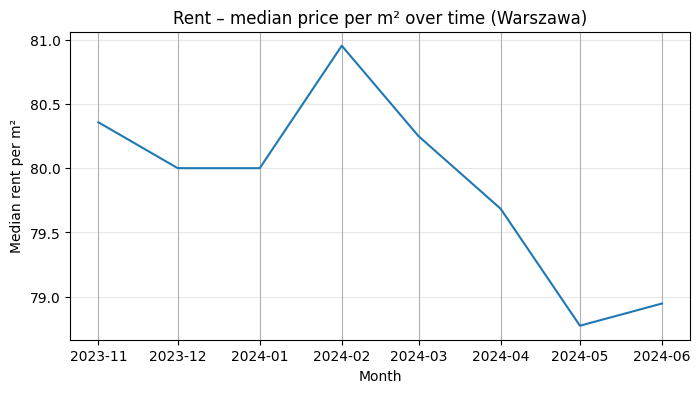

In [18]:
plt.close("all")
plt.figure(figsize=(8, 4))
plt.plot(df_ts_rent["month"], df_ts_rent["median_ppm2"])
plt.title("Rent – median price per m² over time (Warszawa)")
plt.xlabel("Month")
plt.ylabel("Median rent per m²")
plt.grid(axis="y", alpha=0.3)
plt.show()
